In [1]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [2]:
seed = 2724

### Import data

In [3]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [4]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [6]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=2724)

### Use SHAP to explain the model on test data

In [7]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

 99%|===================| 1487/1500 [01:14<00:00]        

This will allow us to see which variables are most important to predicting the outcome.

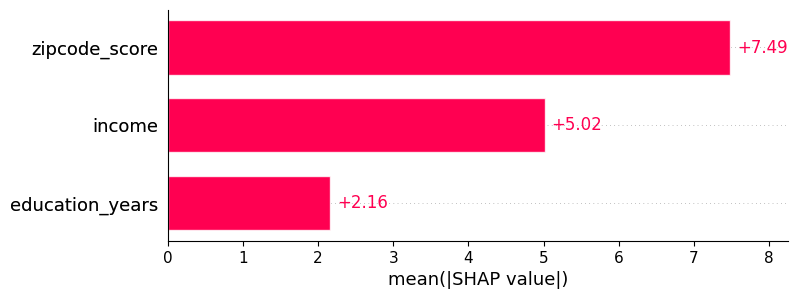

In [8]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [9]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [10]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

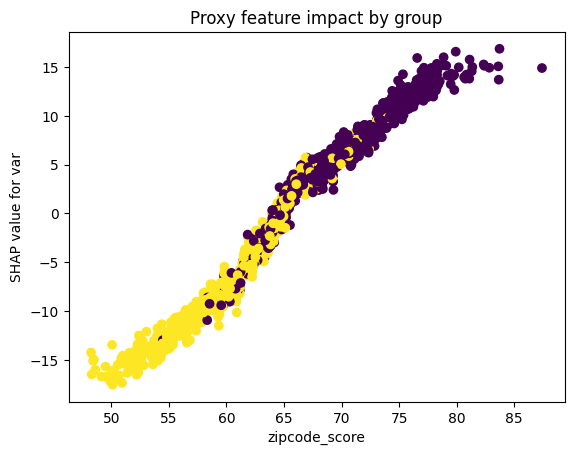

In [11]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

A SHAP value measures how much a specific feature contributes to a model’s prediction for an individual observation, relative to a baseline prediction.Positive SHAP values indicate a feature increases the prediction, while negative values indicate it decreases the prediction.

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

No, the variable group was not used in training the model. The model was trained only on income, education_years, and zipcode_score. The group variable was introduced after.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

Yes, the model’s outcomes are correlated with group. Analysis of SHAP values shows systematic differences in feature impact across groups, particularly for zipcode_score. This shows that even without using group directly, the model’s predictions differ by group due to proxy variables.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

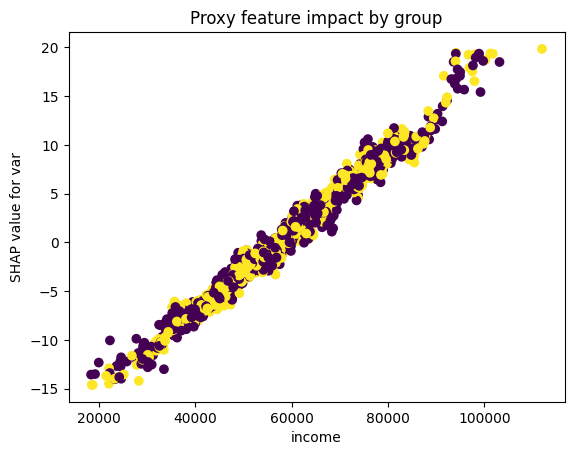

In [13]:
plot_shap("income")

The proxy feature impact plot for income shows much greater overlap between the two groups compared to zipcode_score. While income does influence predictions, its SHAP values are more similarly distributed across groups. In contrast, zipcode_score shows a clear separation between groups, indicating it functions as a stronger proxy variable and contributes more heavily to group-based differences in model outcomes.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

I would ask:

Have you evaluated whether other features besides zipcode_score may also function as proxy variables for protected attributes?

What steps would you take to mitigate the observed bias before deploying this model in a real-world setting?